In [19]:
import pandas as pd  
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error, r2_score  

df = pd.read_csv("delitos.csv", sep=";")

# quitamos espacios, pasamos a mayusculas y nos quedamos solo con mes y año 
# porque queremos analizar la evolucion temporal
df.columns = df.columns.str.strip().str.upper()
df = df[["AÑO", "MES"]]

# pasamos los meses a numeros para usar ml
mes_map = {"ENERO": 1, "FEBRERO": 2, "MARZO": 3, "ABRIL": 4, "MAYO": 5, "JUNIO": 6, "JULIO": 7, "AGOSTO": 8, "SEPTIEMBRE": 9, "OCTUBRE": 10, "NOVIEMBRE": 11, "DICIEMBRE": 12}
df["MES"] = df["MES"].map(mes_map)
df = df.dropna()

# queremos saber delitos por mes asi que agrupamos por año y mes, 
# contamos cantidad de registros y ordenamos cronologicamente
df_g = df.groupby(["AÑO", "MES"]).size().reset_index(name="cantidad")
df_g = df_g.sort_values(["AÑO", "MES"]).reset_index(drop=True)

# creamos columnas guardando los delitos de los ultimos 3 meses
df_g["hace_1mes"] = df_g["cantidad"].shift(1)
df_g["hace_2mes"] = df_g["cantidad"].shift(2)
df_g["hace_3mes"] = df_g["cantidad"].shift(3)
df_g = df_g.dropna()

# no usamos año porque el modelo puede interpretar que los delitos aumentan con el paso del tiempo
X = df_g[["MES", "hace_1mes", "hace_2mes", "hace_3mes"]]
y = df_g["cantidad"]

# dividmos usando una relacion de 80% datos y 20% para test respetando el orden temporal
split = int(len(df_g) * 0.8)
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = round(mean_absolute_error(y_test, y_pred), 2)
r2 = round(r2_score(y_test, y_pred), 2)

# usamos los ultimos datos para construir el input del proximo mes y hacer la prediccion
ultimo = df_g.iloc[-1]
nuevo = pd.DataFrame({
    "MES": [ultimo["MES"] + 1 if ultimo["MES"] < 12 else 1],
    "hace_1mes": [ultimo["cantidad"]],
    "hace_2mes": [ultimo["hace_1mes"]],
    "hace_3mes": [ultimo["hace_2mes"]]
})
pred = int(model.predict(nuevo)[0])
print("MAE:", mae)
print("R2:", r2)
print("Predicción próximo mes:", pred)

MAE: 654.09
R2: 0.27
Predicción próximo mes: 13943


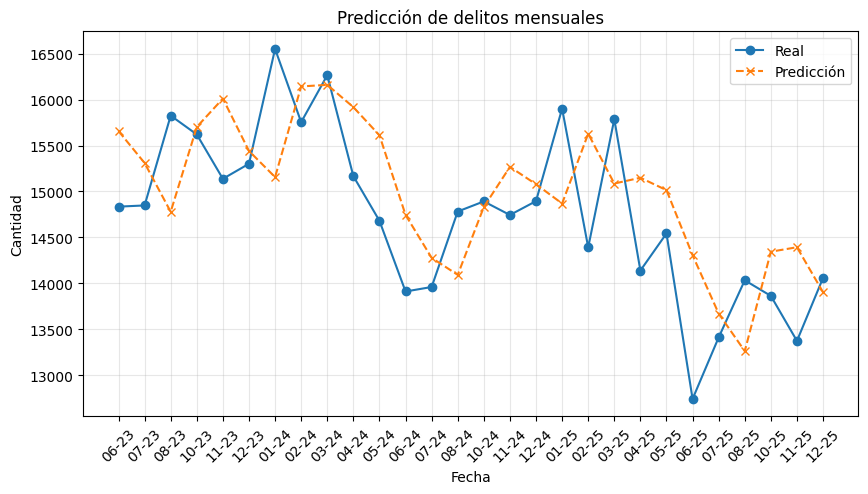

In [ ]:
import matplotlib.pyplot as plt

fechas = df_g.iloc[split:][["AÑO", "MES"]]
labels = (fechas["MES"].astype(int).astype(str).str.zfill(2)+ "-"+ fechas["AÑO"].astype(int).astype(str).str[-2:])

plt.figure(figsize=(10,5))

plt.plot(labels, y_test.values, marker="o", label="Real")
plt.plot(labels, y_pred, marker="x", linestyle="--", label="Predicción")

plt.title("Predicción de delitos mensuales")
plt.xlabel("Fecha")
plt.ylabel("Cantidad")

plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.show()